# Introduction to AI Fundamentals

> Goal of this notebook: Build your overall understanding of AI, learn what each research direction does, and provide a roadmap for further in-depth study.

**Content Outline:**
1. What is Artificial Intelligence
2. AI Knowledge Landscape
3. Essential Mathematical Foundations
4. Machine Learning (The Core Paradigm of AI)
5. Six Major Research Directions in Detail
6. Learning Path Planning

In [2]:
# !pip install numpy matplotlib networkx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print('Environment ready')

Environment ready


---
## Chapter 1: What is Artificial Intelligence

**Definition:** The science and technology of enabling machines to simulate, extend, and expand human intelligence.

### 1.1 Three Levels of AI

| Level | Name | Status | Description |
|------|------|------|------|
| ANI | Narrow AI | **Achieved** | Can only complete specific tasks, such as playing chess, translation, image recognition |
| AGI | General AI | In Research | Reason, learn, and adapt in any domain like humans |
| ASI | Super AI | Theoretical | Surpasses human intelligence in all aspects |

> Everything we learn and use today is **ANI (Narrow AI)**.

### 1.2 Brief History of AI Development

```
1950s  Turing Test proposed, AI born as a discipline
1960s  First AI boom: symbolic reasoning, expert systems
1980s  First AI winter: insufficient computing power, limitations of rule-based systems exposed
1990s  Rise of machine learning: statistical methods replace rule-based methods
2006   Deep learning breakthrough: Hinton proposes pre-training of deep neural networks
2012   AlexNet wins ImageNet: the deep learning era begins
2017   Transformer architecture born: starting point of the NLP revolution
2020   GPT-3: large language models demonstrate emergent abilities
2022   ChatGPT released: AI enters the public eye
2024+  Multimodal, Agents become frontier hotspots
```

### 1.3 What AI Can Do (Current Capability Boundaries)

| Good At | Not Good At |
|------|--------|
| Pattern recognition (image, speech, text) | True causal reasoning |
| Finding patterns in large-scale data | Continual learning (without forgetting) |
| Generating text, images, code | Commonsense physical world understanding |
| Winning in games with clear rules | Generalization in low-data scenarios |

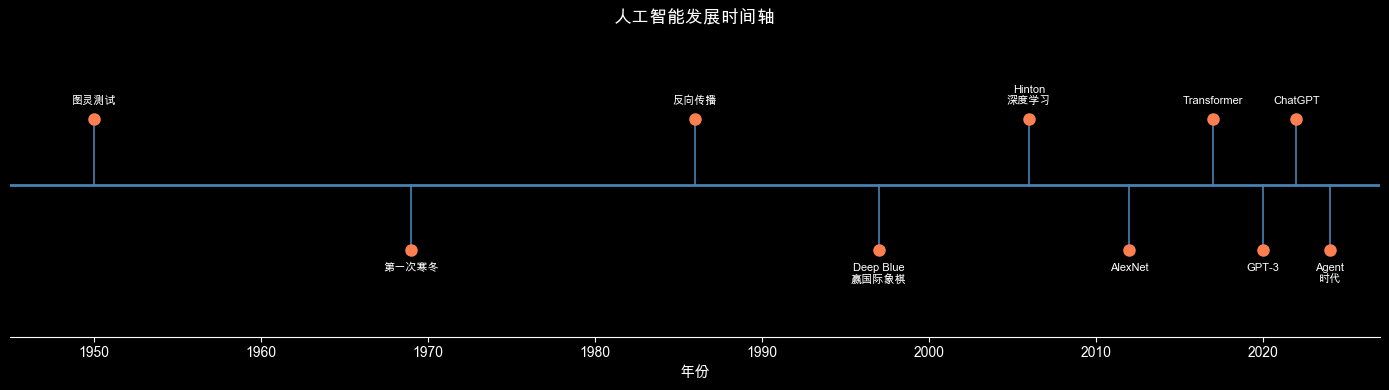

In [3]:
# Visualize AI development timeline
fig, ax = plt.subplots(figsize=(14, 4))

events = [
    (1950, 'Turing Test'),
    (1969, 'First Winter'),
    (1986, 'Backpropagation'),
    (1997, 'Deep Blue\nWins Chess'),
    (2006, 'Hinton\nDeep Learning'),
    (2012, 'AlexNet'),
    (2017, 'Transformer'),
    (2020, 'GPT-3'),
    (2022, 'ChatGPT'),
    (2024, 'Agent\nEra'),
]

ax.axhline(0, color='steelblue', lw=2)
for i, (year, label) in enumerate(events):
    y = 0.3 if i % 2 == 0 else -0.3
    ax.plot([year, year], [0, y], 'steelblue', lw=1.2)
    ax.plot(year, y, 'o', color='coral', ms=8, zorder=5)
    ax.text(year, y + (0.06 if y > 0 else -0.06), label,
            ha='center', va='bottom' if y > 0 else 'top', fontsize=8)

ax.set_xlim(1945, 2027)
ax.set_ylim(-0.7, 0.7)
ax.set_yticks([])
ax.set_xlabel('Year', fontsize=11)
ax.set_title('AI Development Timeline', fontsize=13)
ax.spines[['left','top','right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## Chapter 2: AI Knowledge Landscape

AI is a big family; the diagram below shows the relationships between its branches:

```
Artificial Intelligence
│
├── Machine Learning ← The main body of AI today
│   │
│   ├── Traditional Machine Learning (Linear Regression, SVM, Decision Trees, Clustering...)
│   │
│   └── Deep Learning ← Neural networks at the core
│       │
│       ├── Computer Vision (CV)
│       ├── Natural Language Processing (NLP) / Large Language Models (LLM)
│       ├── Generative AI
│       ├── Multimodal AI
│       └── Reinforcement Learning (RL) ← Can also be independent of deep learning
│
├── Knowledge Representation and Reasoning (Symbolic AI, Knowledge Graphs)
│
└── Robotics and Embodied Intelligence (Robotics & Embodied AI)
```

**Core Relationship:** Deep learning is the underlying technology behind most current AI breakthroughs, but AI is not equal to deep learning.

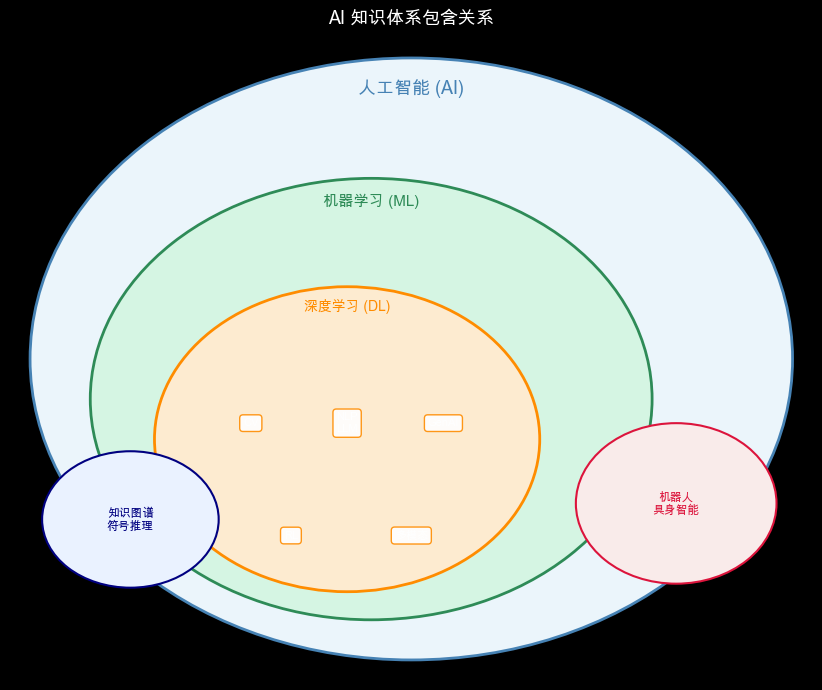

In [4]:
# Visualize the containment relationships of the AI knowledge system
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.set_aspect('equal')
ax.axis('off')

from matplotlib.patches import FancyBboxPatch, Ellipse

# Outermost layer: AI
ai = Ellipse((5, 4), 9.5, 7.5, fill=True, facecolor='#EBF5FB', edgecolor='steelblue', lw=2)
ax.add_patch(ai)
ax.text(5, 7.3, 'Artificial Intelligence (AI)', ha='center', fontsize=13, fontweight='bold', color='steelblue')

# Machine Learning
ml = Ellipse((4.5, 3.5), 7, 5.5, fill=True, facecolor='#D5F5E3', edgecolor='seagreen', lw=2)
ax.add_patch(ml)
ax.text(4.5, 5.9, 'Machine Learning (ML)', ha='center', fontsize=11, fontweight='bold', color='seagreen')

# Deep Learning
dl = Ellipse((4.2, 3.0), 4.8, 3.8, fill=True, facecolor='#FDEBD0', edgecolor='darkorange', lw=2)
ax.add_patch(dl)
ax.text(4.2, 4.6, 'Deep Learning (DL)', ha='center', fontsize=10, fontweight='bold', color='darkorange')

# Embodied AI (external)
rob = Ellipse((8.3, 2.2), 2.5, 2.0, fill=True, facecolor='#F9EBEA', edgecolor='crimson', lw=1.5)
ax.add_patch(rob)
ax.text(8.3, 2.2, 'Robotics\nEmbodied AI', ha='center', va='center', fontsize=8.5, color='crimson')

# Knowledge Graph (external)
kg = Ellipse((1.5, 2.0), 2.2, 1.7, fill=True, facecolor='#EAF2FF', edgecolor='navy', lw=1.5)
ax.add_patch(kg)
ax.text(1.5, 2.0, 'Knowledge Graph\nSymbolic Reasoning', ha='center', va='center', fontsize=8.5, color='navy')

# Sub-directions within Deep Learning
for x, y, name in [(3.0, 3.2, 'CV'), (4.2, 3.2, 'NLP\nLLM'), (5.4, 3.2, 'GenAI'),
                    (3.5, 1.8, 'RL'), (5.0, 1.8, 'Multimodal')]:
    ax.text(x, y, name, ha='center', va='center', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkorange', alpha=0.9))

ax.set_title('AI Knowledge System Containment', fontsize=13, pad=10)
plt.tight_layout()
plt.show()

---
## Chapter 3: Essential Mathematical Foundations

The foundation of AI is mathematics. The table below shows where each math module is used and to what extent you need to master it:

| Math Module | Core Concepts | Usage in AI | Importance |
|----------|----------|----------------|----------|
| **Linear Algebra** | Matrix/vector operations, eigenvalues | Data representation, neural network layer computation, PCA | ★★★★★ |
| **Calculus** | Derivatives, partial derivatives, chain rule | Gradient descent, backpropagation | ★★★★★ |
| **Probability Theory** | Conditional probability, distributions, Bayes | Uncertainty modeling, generative models | ★★★★☆ |
| **Statistics** | Mean/variance, hypothesis testing | Data analysis, model evaluation | ★★★☆☆ |
| **Optimization Theory** | Convex optimization, gradient descent variants | Model training | ★★★★☆ |
| **Information Theory** | Entropy, KL divergence, mutual information | Loss functions, generative models | ★★★☆☆ |

> **Learning Advice:** Linear algebra + calculus are the highest priority. You can learn AI while filling in math gaps; you don't need to finish all math before starting.

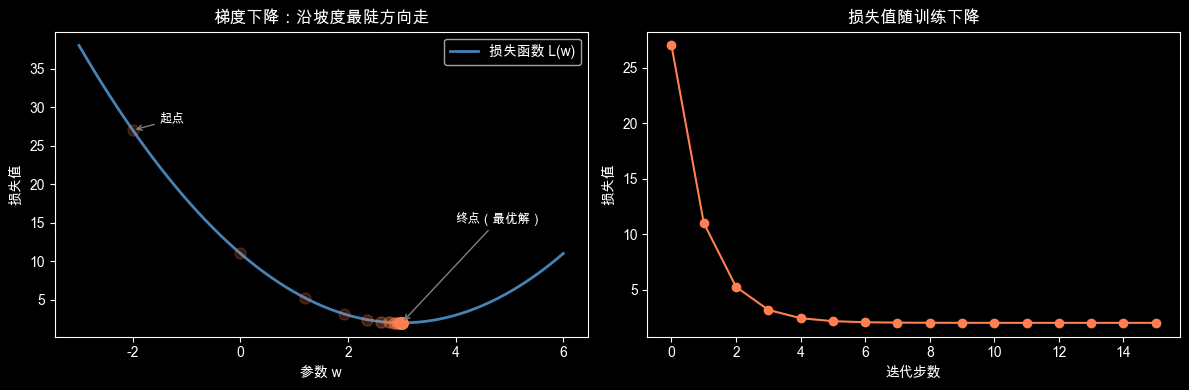

Initial w=-2.0 → Final w=2.9976 (target value is 3)


In [5]:
# Demonstrate gradient descent — the core optimization concept in AI
def loss(w): return (w - 3) ** 2 + 2   # Optimal solution w=3
def grad(w): return 2 * (w - 3)

w, lr = -2.0, 0.2
history = [w]
for _ in range(15):
    w = w - lr * grad(w)
    history.append(w)

w_range = np.linspace(-3, 6, 200)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(w_range, loss(w_range), 'steelblue', lw=2, label='Loss function L(w)')
for i, wi in enumerate(history):
    axes[0].plot(wi, loss(wi), 'o', color='coral',
                 alpha=max(0.2, i/len(history)), ms=8)
axes[0].annotate('Start', (history[0], loss(history[0])), xytext=(-1.5, 28),
                arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)
axes[0].annotate('End (Optimal)', (history[-1], loss(history[-1])), xytext=(4, 15),
                arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)
axes[0].set_xlabel('Parameter w')
axes[0].set_ylabel('Loss value')
axes[0].set_title('Gradient Descent: Walk along the steepest slope')
axes[0].legend()

axes[1].plot(range(len(history)), [loss(w) for w in history], 'o-', color='coral')
axes[1].set_xlabel('Iteration steps')
axes[1].set_ylabel('Loss value')
axes[1].set_title('Loss decreases during training')

plt.tight_layout()
plt.show()
print(f'Initial w={history[0]:.1f} → Final w={history[-1]:.4f} (target value is 3)')

---
## Chapter 4: Machine Learning — The Core Paradigm of AI

Machine learning is the dominant methodology of AI today, divided into three major paradigms:

### 4.1 Three Major Paradigms

| Paradigm | Labels | Goal | Typical Algorithms |
|------|----------|------|----------|
| **Supervised Learning** | Yes (input + answer) | Learn input→output mapping | Linear regression, decision trees, SVM, random forest |
| **Unsupervised Learning** | No | Discover internal data structure | K-Means, PCA, autoencoders |
| **Reinforcement Learning** | Reward signal | Learn to act in an environment to maximize cumulative reward | Q-Learning, PPO, AlphaGo |

### 4.2 General Learning Process

```
Collect data → Data cleaning → Feature engineering → Select model → Train → Evaluate → Tune → Deploy
```

### 4.3 Core Challenge: Bias and Variance

- **Underfitting (high bias)**: Model is too simple, hasn't learned the pattern
- **Overfitting (high variance)**: Model memorizes training data, poor generalization
- **Goal**: Find a balance between bias and variance

> For detailed algorithm implementations, please refer to `ml-fundamentals.ipynb` in the same directory.

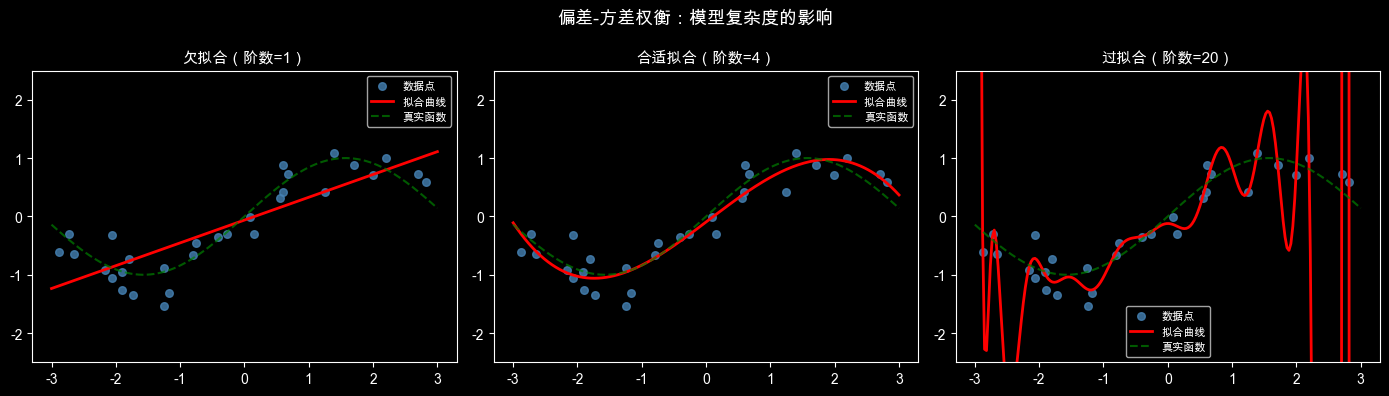

In [6]:
# Intuitive comparison of underfitting / good fit / overfitting
np.random.seed(42)
X_demo = np.sort(np.random.rand(30) * 6 - 3)
y_demo = np.sin(X_demo) + np.random.randn(30) * 0.3

from numpy.polynomial import polynomial as P

x_plot = np.linspace(-3, 3, 200)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, deg, title in zip(axes,
                           [1, 4, 20],
                           ['Underfitting (degree=1)', 'Good Fit (degree=4)', 'Overfitting (degree=20)']):
    coef = np.polyfit(X_demo, y_demo, deg)
    ax.scatter(X_demo, y_demo, color='steelblue', s=30, alpha=0.8, label='Data points')
    ax.plot(x_plot, np.polyval(coef, x_plot), 'r-', lw=2, label=f'Fitted curve')
    ax.plot(x_plot, np.sin(x_plot), 'g--', lw=1.5, alpha=0.7, label='True function')
    ax.set_title(title, fontsize=11)
    ax.set_ylim(-2.5, 2.5)
    ax.legend(fontsize=8)

plt.suptitle('Bias-Variance Tradeoff: Impact of Model Complexity', fontsize=13)
plt.tight_layout()
plt.show()

---
## Chapter 5: Six Major Research Directions in Detail

The following six directions are the most active areas in AI today, each developed based on machine learning foundations.

### Direction 1: Deep Learning

**In one sentence:** Automatically learn hierarchical representations of data using multi-layer neural networks; it is the underlying foundation for all other deep learning directions.

**Core Idea:**
```
Input layer → [Hidden layer 1] → [Hidden layer 2] → ... → [Hidden layer N] → Output layer
   Each layer learns more abstract features (pixels → edges → shapes → objects)
```

**Key Concepts:**
- **Neurons & Activation Functions**: ReLU, Sigmoid, Tanh
- **Backpropagation**: Compute gradients via the chain rule to update weights
- **Regularization**: Dropout, Batch Normalization
- **Network Architectures**: MLP, CNN, RNN, Transformer

**Typical Applications:** Image recognition, speech recognition, the foundation of all AI products

**Prerequisites:** Linear algebra + calculus (gradients) + machine learning basics

**Learning Path:**
```
Perceptron → Multi-Layer Perceptron (MLP) → Backpropagation → CNN → RNN/LSTM → Transformer
```

**Beginner Resources:** Andrew Ng's "Deep Learning Specialization" (Coursera), "Dive into Deep Learning" (d2l.ai)

Input: [[ 0.5 -0.3  0.8]]
Hidden layer output (ReLU): [[0.12  0.411 0.16  1.165]]
Final output (Sigmoid): 0.5745  → Prediction probability is 57.45%


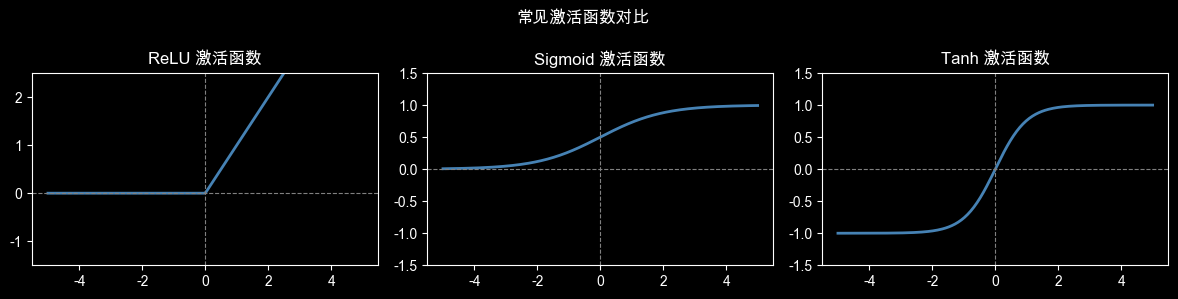

In [7]:
# Simulate forward propagation of a simple neural network
def sigmoid(x): return 1 / (1 + np.exp(-x))
def relu(x):    return np.maximum(0, x)

np.random.seed(0)
X_nn = np.array([[0.5, -0.3, 0.8]])     # 1 sample, 3 features
W1 = np.random.randn(3, 4) * 0.5        # Layer 1: 3→4
W2 = np.random.randn(4, 1) * 0.5        # Layer 2: 4→1

h1 = relu(X_nn @ W1)                    # Hidden layer
out = sigmoid(h1 @ W2)                  # Output layer

print('Input:', X_nn)
print('Hidden layer output (ReLU):', h1.round(3))
print(f'Final output (Sigmoid): {out[0][0]:.4f}  → Prediction probability is {out[0][0]:.2%}')

# Visualize activation functions
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
x = np.linspace(-5, 5, 200)
for ax, (name, fn) in zip(axes, [('ReLU', relu), ('Sigmoid', sigmoid),
                                   ('Tanh', np.tanh)]):
    ax.plot(x, fn(x), color='steelblue', lw=2)
    ax.axhline(0, color='gray', lw=0.8, linestyle='--')
    ax.axvline(0, color='gray', lw=0.8, linestyle='--')
    ax.set_title(f'{name} Activation Function')
    ax.set_ylim(-1.5, 2.5 if name == 'ReLU' else 1.5)
plt.suptitle('Comparison of Common Activation Functions', fontsize=12)
plt.tight_layout()
plt.show()

### Direction 2: Natural Language Processing (NLP) / Large Language Models (LLM)

**In one sentence:** Enable machines to understand, generate, and translate human language; LLM is its current strongest form.

**Development Timeline:**
```
Bag of Words (BOW) → Word2Vec (word embeddings) → RNN/LSTM → Transformer → BERT → GPT → LLM
```

**Core Technologies:**
- **Word Embedding**: Map words to dense vectors that capture semantic relationships
- **Transformer & Attention Mechanism**: Process sequences in parallel, capture long-range dependencies
- **Pre-train & Fine-tune**: Large-scale unsupervised pre-training + downstream task fine-tuning
- **RLHF**: Reinforcement learning from human feedback to make model outputs align better with human preferences

**Typical Tasks:** Text classification, machine translation, Q&A, summarization, code generation, dialogue

**Typical Models:** BERT (understanding), GPT series (generation), LLaMA, Claude

**Prerequisites:** Deep learning basics (especially Transformer) + Python + probability theory

**Beginner Resources:** HuggingFace official tutorials, "Speech and Language Processing" (Jurafsky)

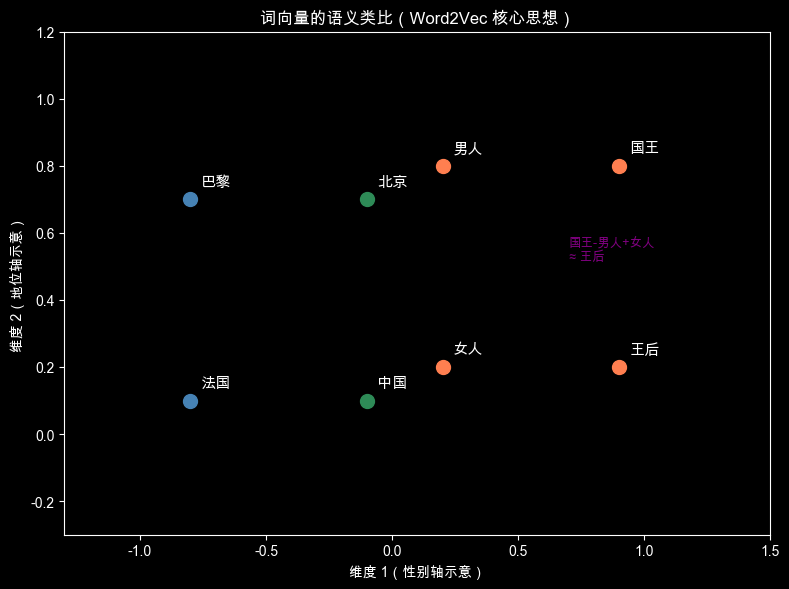

In [8]:
# Demonstrate semantic relationships of word vectors (using random vectors to illustrate the concept)
# In real scenarios, use gensim or transformers libraries
words = ['king', 'queen', 'man', 'woman', 'Paris', 'France', 'Beijing', 'China']
np.random.seed(7)
# Manually designed semantically reasonable 2D embeddings for demonstration
embeddings = {
    'king':  np.array([0.9, 0.8]),
    'queen':  np.array([0.9, 0.2]),
    'man':  np.array([0.2, 0.8]),
    'woman':  np.array([0.2, 0.2]),
    'Paris':  np.array([-0.8, 0.7]),
    'France':  np.array([-0.8, 0.1]),
    'Beijing':  np.array([-0.1, 0.7]),
    'China':  np.array([-0.1, 0.1]),
}

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['coral']*4 + ['steelblue']*2 + ['seagreen']*2
for (word, vec), c in zip(embeddings.items(), colors):
    ax.scatter(*vec, color=c, s=100, zorder=5)
    ax.text(vec[0]+0.04, vec[1]+0.04, word, fontsize=11)

# Semantic analogy arrow: king - man + woman ≈ queen
v = embeddings['king'] - embeddings['man'] + embeddings['woman']
ax.annotate('', xy=embeddings['queen'], xytext=v,
            arrowprops=dict(arrowstyle='->', color='purple', lw=1.5))
ax.text(0.7, 0.52, 'king-man+woman\n≈ queen', fontsize=9, color='purple')

ax.set_xlim(-1.3, 1.5)
ax.set_ylim(-0.3, 1.2)
ax.set_title('Semantic Analogy of Word Vectors (Core Idea of Word2Vec)', fontsize=12)
ax.set_xlabel('Dimension 1 (gender axis illustration)')
ax.set_ylabel('Dimension 2 (status axis illustration)')
plt.tight_layout()
plt.show()

### Direction 3: Computer Vision (CV)

**In one sentence:** Enable machines to understand the content of images and videos.

**Core Task Hierarchy:**
```
Image classification → "This image is a cat"
Object detection → "There is a cat in the upper left, and a dog on the right" (location + category)
Semantic segmentation → "Which category does each pixel belong to"
Instance segmentation → "The outline of each individual object"
Image generation → "Generate a realistic image of a cat"
```

**Core Technologies:**
- **Convolutional Neural Networks (CNN)**: Local receptive fields + weight sharing, efficiently extract image features
- **Classic Architectures**: LeNet → AlexNet → VGG → ResNet → ViT (Vision Transformer)
- **Object Detection**: YOLO series, Faster R-CNN
- **Image Generation**: GAN, Diffusion Model (Stable Diffusion)

**Typical Applications:** Face recognition, autonomous driving, medical imaging, industrial quality inspection, image generation

**Prerequisites:** Deep learning (CNN) + linear algebra

**Beginner Resources:** CS231n (Stanford CV course), PyTorch official tutorials

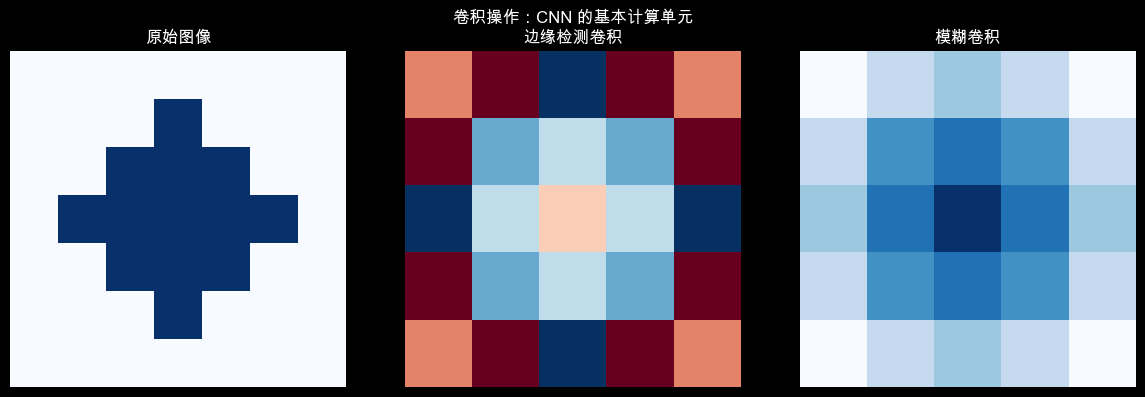

In [9]:
# Demonstrate convolution operation — the core computation of CV
image = np.array([
    [0,0,0,0,0,0,0],
    [0,0,0,1,0,0,0],
    [0,0,1,1,1,0,0],
    [0,1,1,1,1,1,0],
    [0,0,1,1,1,0,0],
    [0,0,0,1,0,0,0],
    [0,0,0,0,0,0,0],
], dtype=float)

# Edge detection convolution kernel (Sobel)
kernel_edge = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]])
# Blur convolution kernel
kernel_blur = np.ones((3,3)) / 9

def conv2d(img, kernel):
    h, w = img.shape
    kh, kw = kernel.shape
    out = np.zeros((h-kh+1, w-kw+1))
    for i in range(h-kh+1):
        for j in range(w-kw+1):
            out[i,j] = (img[i:i+kh, j:j+kw] * kernel).sum()
    return out

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image, cmap='Blues')
axes[0].set_title('Original Image')
axes[1].imshow(conv2d(image, kernel_edge), cmap='RdBu')
axes[1].set_title('Edge Detection Convolution')
axes[2].imshow(conv2d(image, kernel_blur), cmap='Blues')
axes[2].set_title('Blur Convolution')
for ax in axes: ax.axis('off')
plt.suptitle('Convolution Operation: The Basic Computation Unit of CNN', fontsize=12)
plt.tight_layout()
plt.show()

### Direction 4: Reinforcement Learning (RL)

**In one sentence:** An agent learns optimal policies through interaction with the environment and reward signals, without manual labeling.

**Core Framework:**
```
                    Action(Action)
Agent(Agent) ─────────────────→ Environment(Environment)
     ↑                                  │
     │ State(State) + Reward(Reward)        │
     └──────────────────────────────────┘
```

**Key Concepts:**
- **Policy π**: State→action mapping function (what needs to be learned)
- **Value Function**: Evaluates how good a state is
- **Q-Learning**: Learn the long-term value of each (state, action) pair
- **Policy Gradient**: Directly optimize the policy

**Algorithm Development:**
```
Q-Learning → DQN (Deep Q-Network) → A3C → PPO → SAC
```

**Typical Applications:** Game AI (AlphaGo, AlphaStar), robot control, recommendation systems, RLHF training for LLMs

**Prerequisites:** Probability theory + dynamic programming + deep learning basics

**Beginner Resources:** Sutton & Barto "Reinforcement Learning: An Introduction" (free online edition)

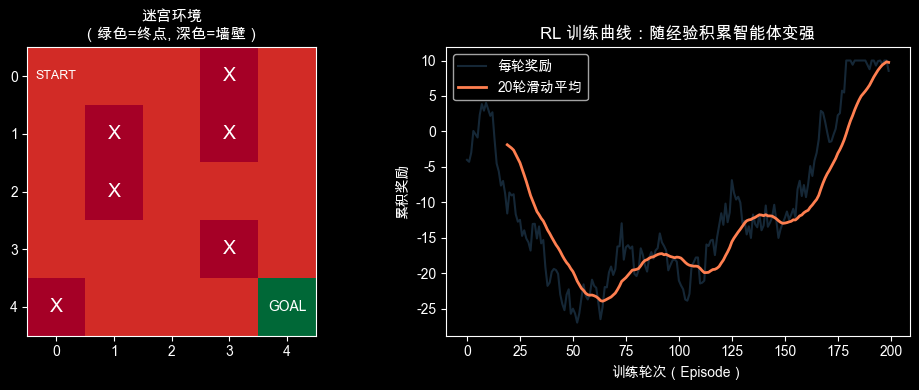

In [10]:
# Demonstrate Q-Learning solving a simple maze problem
# Maze: 0=open space, -1=wall, +10=goal
MAZE = np.array([
    [0,  0,  0, -1,  0],
    [0, -1,  0, -1,  0],
    [0, -1,  0,  0,  0],
    [0,  0,  0, -1,  0],
    [-1, 0,  0,  0, 10],
])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cmap = plt.cm.RdYlGn
axes[0].imshow(MAZE, cmap=cmap, vmin=-1, vmax=10)
axes[0].set_title('Maze Environment\n(Green=Goal, Dark=Walls)', fontsize=11)
axes[0].text(4, 4, 'GOAL', ha='center', va='center', fontweight='bold', fontsize=10)
axes[0].text(0, 0, 'START', ha='center', va='center', fontsize=9)
for i in range(5):
    for j in range(5):
        if MAZE[i,j] == -1:
            axes[0].text(j, i, 'X', ha='center', va='center', color='white', fontsize=14)

# RL core: rewards accumulate over time
np.random.seed(42)
episodes = 200
rewards = []
r = -5
for ep in range(episodes):
    r = r + np.random.randn() * 2 + (ep / episodes) * 0.3
    rewards.append(min(r, 10))

window = 20
smooth = np.convolve(rewards, np.ones(window)/window, mode='valid')
axes[1].plot(rewards, alpha=0.3, color='steelblue', label='Reward per episode')
axes[1].plot(range(window-1, episodes), smooth, color='coral', lw=2, label=f'{window}-episode moving average')
axes[1].set_xlabel('Training Episode')
axes[1].set_ylabel('Cumulative Reward')
axes[1].set_title('RL Training Curve: Agent Improves with Experience')
axes[1].legend()

plt.tight_layout()
plt.show()

### Direction 5: Generative AI

**In one sentence:** Enable models not just to "analyze" data, but also to "create" new data (text, images, audio, video).

**Main Technical Approaches:**

| Technology | Principle | Representative Models | Good at Generating |
|------|------|----------|----------|
| **GAN** | Generator vs Discriminator adversarial training | StyleGAN | Realistic images |
| **VAE** | Encode to probability distribution, then decode | VQVAE | Controllable generation |
| **Diffusion Model** | Gradually denoise to recover image | DALL-E 3, Stable Diffusion | High-quality images |
| **Autoregressive Model (AR)** | Predict next token sequentially | GPT, LLaMA | Text, code |

**Core Idea of GAN:**
```
Random noise → [Generator G] → Fake samples
                              ↓ both inputs
Real data ──────────────→ [Discriminator D] → Real/Fake
    G wins by fooling D, D wins by detecting G → Mutual improvement through adversarial training
```

**Typical Applications:** Text-to-image (Midjourney), text-to-video (Sora), code generation (Copilot), speech synthesis

**Prerequisites:** Deep learning (Transformer architecture) + probability theory

**Beginner Resources:** HuggingFace Diffusers documentation, OpenAI technical blog

### Direction 6: Multimodal AI

**In one sentence:** Enable models to simultaneously understand and process multiple types of information (text, images, audio, video), getting closer to human perception.

**Why is it important?**  
Human understanding of the world is inherently multimodal — we see with our eyes, hear with our ears, and think in language. Single-modal AI is handicapped.

**Main Tasks:**
| Task | Description | Representative Models |
|------|------|----------|
| Image-text alignment | Semantic matching between images and text descriptions | CLIP |
| Visual Question Answering (VQA) | "How many cats are in the picture?" | GPT-4V, Gemini |
| Image Captioning | Automatically generate image descriptions | BLIP |
| Text-to-image | Generate images from text descriptions | DALL-E, Midjourney |
| Video understanding | Understand video content | Gemini 1.5 Pro |

**Technical Foundation:** Transformer (cross-modal attention) + Contrastive Learning

**Core Idea:**
```
Image encoder ──┐
             ├→ Align to the same semantic space → Cross-modal reasoning
Text encoder ──┘
```

**Prerequisites:** NLP basics (Transformer) + CV basics (CNN/ViT)

**Beginner Resources:** CLIP paper (OpenAI), HuggingFace Transformers multimodal examples

---
## Chapter 6: Learning Path Planning

### 6.1 Prerequisite Dependencies for Each Direction

```
Mathematical Foundations (Linear Algebra + Calculus + Probability)
    ↓
Python + NumPy + Data Processing
    ↓
Machine Learning Basics (Supervised / Unsupervised) ← ml-fundamentals.ipynb
    ↓
Deep Learning Basics (Neural Networks + Backpropagation + PyTorch/TensorFlow)
    ↓ ↓ ↓ ↓ ↓
  CV  NLP  RL  GenAI  ←──→  Multimodal (requires CV + NLP)
```

### 6.2 Choose Direction Based on Your Goal

| Your Goal | Recommended Main Direction | Notes |
|----------|--------------|------|
| Build AI products / application development | NLP / LLM + Multimodal | Call APIs, fine-tune models |
| Do image recognition / autonomous driving | Computer Vision (CV) | Requires solid CNN knowledge |
| Build game AI / robots | Reinforcement Learning (RL) | High mathematical requirements |
| Build AIGC / creative tools | Generative AI | Diffusion + Transformer |
| Do AI research / publish papers | Deep learning theory | Requires the most solid mathematics |

### 6.3 Recommended First-Phase Learning Sequence (3-6 Months)

```
Week 1-2   Review/learn Python + NumPy + Pandas + Matplotlib
Week 3-4   Math foundations: Linear Algebra (3Blue1Brown videos)
Week 5-6   Machine learning basics (ml-fundamentals.ipynb in this directory)
Week 7-8   Calculus/gradient descent + backpropagation by hand
Week 9-12  Deep learning basics: MLP → CNN → RNN → Transformer (PyTorch)
Week 13+   Choose a direction to go deep (NLP / CV / RL / GenAI)
```

### 6.4 Recommended Core Tool Stack

| Purpose | Tools |
|------|------|
| Numerical computation | NumPy, SciPy |
| Data processing | Pandas |
| Machine learning | scikit-learn |
| Deep learning framework | PyTorch (preferred for academia/research), TensorFlow/Keras (industrial deployment) |
| NLP | HuggingFace Transformers |
| CV | OpenCV, torchvision |
| Experiment management | Weights & Biases (wandb) |
| Deployment | FastAPI + Docker |

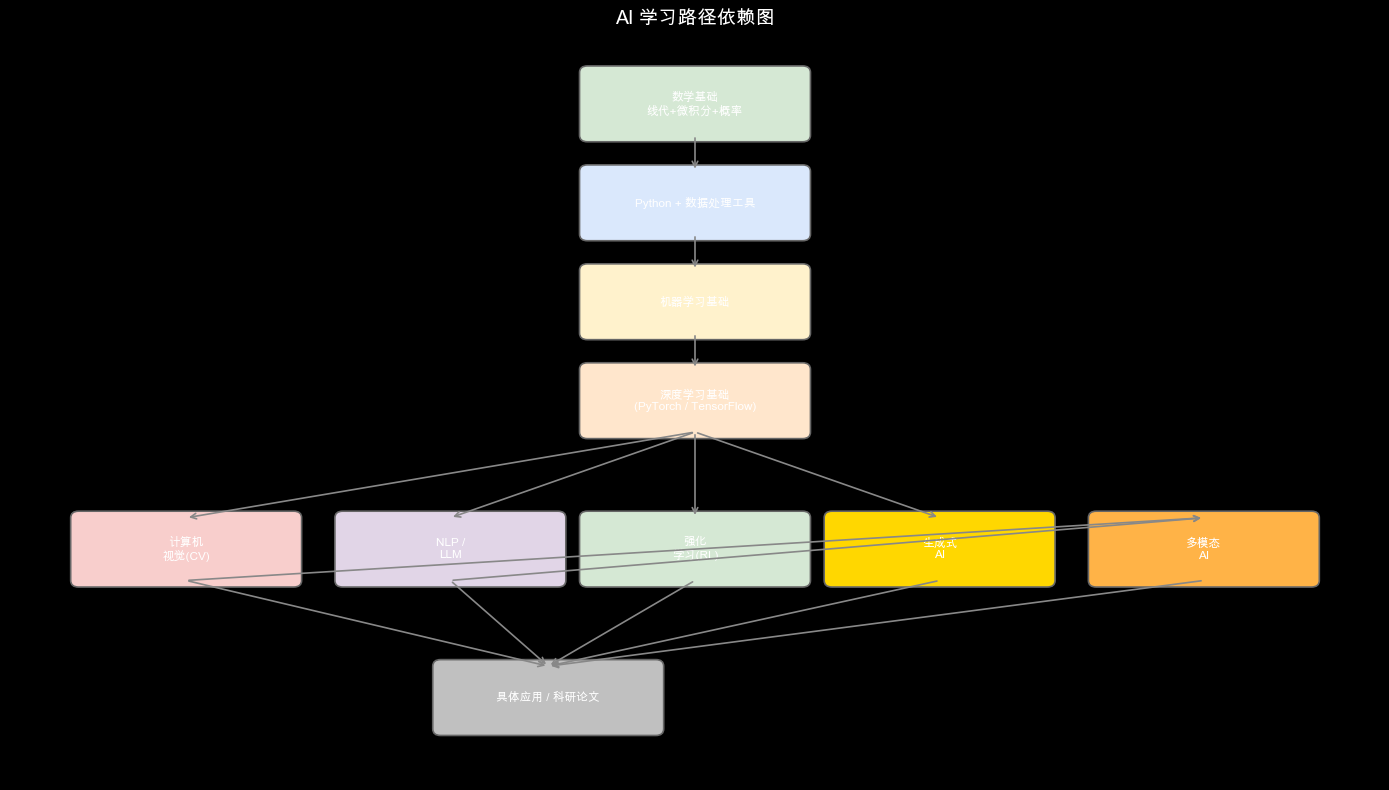

In [11]:
# Draw learning path dependency graph
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 9)
ax.axis('off')

nodes = [
    # (x, y, label, color)
    (7,   8.2, 'Math Foundations\nLinear Algebra+Calculus+Probability', '#D5E8D4'),
    (7,   7.0, 'Python + Data Processing Tools', '#DAE8FC'),
    (7,   5.8, 'Machine Learning Basics', '#FFF2CC'),
    (7,   4.6, 'Deep Learning Basics\n(PyTorch / TensorFlow)', '#FFE6CC'),
    (1.8, 2.8, 'Computer\nVision (CV)', '#F8CECC'),
    (4.5, 2.8, 'NLP /\nLLM', '#E1D5E7'),
    (7.0, 2.8, 'Reinforcement\nLearning (RL)', '#D5E8D4'),
    (9.5, 2.8, 'Generative\nAI', '#FFD700'),
    (12.2,2.8, 'Multimodal\nAI', '#FFB347'),
    (5.5, 1.0, 'Applications / Research Papers', '#C0C0C0'),
]

edges = [(0,1),(1,2),(2,3),(3,4),(3,5),(3,6),(3,7),(4,8),(5,8),(3,8)]

for x, y, label, color in nodes:
    ax.add_patch(mpatches.FancyBboxPatch((x-1.1, y-0.38), 2.2, 0.76,
                 boxstyle='round,pad=0.08', facecolor=color, edgecolor='#666', lw=1.2))
    ax.text(x, y, label, ha='center', va='center', fontsize=8.5, fontweight='bold')

# Arrows
arrow_pairs = [
    (0,1),(1,2),(2,3),
    (3, 4),(3, 5),(3, 6),(3, 7),
    (4, 8),(5, 8),
    (4, len(nodes)-1),(5, len(nodes)-1),(6, len(nodes)-1),
    (7, len(nodes)-1),(8, len(nodes)-1),
]
for s, e in arrow_pairs:
    x0, y0 = nodes[s][0], nodes[s][1] - 0.38
    x1, y1 = nodes[e][0], nodes[e][1] + 0.38
    ax.annotate('', xy=(x1,y1), xytext=(x0,y0),
                arrowprops=dict(arrowstyle='->', color='#888', lw=1.2,
                                connectionstyle='arc3,rad=0.0'))

ax.set_title('AI Learning Path Dependency Graph', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

---
## Appendix: Quick Reference Table for All Directions

| Direction | Core Problem | Key Technologies | Typical Applications | Math Difficulty | Recommended Beginner Resources |
|------|----------|----------|----------|----------|--------------|
| **Machine Learning** | Learn patterns from data | Linear models, tree models, SVM | Classification/regression/clustering | ★★☆ | scikit-learn docs |
| **Deep Learning** | Hierarchical feature learning | MLP, CNN, RNN, Transformer | Foundation for all deep directions | ★★★ | d2l.ai, CS231n |
| **NLP / LLM** | Language understanding and generation | Transformer, BERT, GPT | Dialogue, translation, summarization | ★★★ | HuggingFace tutorials |
| **Computer Vision** | Image/video understanding | CNN, ViT, YOLO | Recognition, detection, generation | ★★★ | CS231n |
| **Reinforcement Learning** | Sequential decision optimization | Q-Learning, PPO | Games, robots | ★★★★ | Sutton & Barto book |
| **Generative AI** | Create new content | GAN, diffusion models, GPT | Text-to-image, text-to-video | ★★★★ | HuggingFace Diffusers |
| **Multimodal AI** | Cross-modal understanding | CLIP, cross-modal Transformer | VQA, image-text matching | ★★★★ | CLIP paper, LLaVA |
